---
tags: [algorithm, block-encoding, amplitude-amplification]
---

# Amplifying Block-Encoding Post-Selection

A block encoding applies a non-unitary operator $A$ by embedding it in a
larger unitary and **post-selecting** on the signal (ancilla) register being
measured all-zero. That measurement succeeds with probability

$$
a \;=\; \frac{\lVert A\lvert\psi\rangle\rVert^2}{\alpha^2},
$$

where $\alpha$ is the subnormalization. The stronger the filter, the smaller
$a$ becomes, and the expected number of repetitions grows as $1/a$. Amplitude
amplification cuts that to $O(1/\sqrt{a})$.

One emitter, `qmc.amplitude_amplification`, applies a **schedule** object to
any state preparation with the `(signal, system)` ABI that every
`LCUBlockEncoding` already uses. Two schedules are available:

* `qmc.standard_amplification_schedule(k)` — the Brassard-Hoyer-Mosca-Tapp
  iterate $Q = -A S_0 A^\dagger S_{\mathrm{good}}$
  {cite:p}`10.1090/conm/305/05215`. After $k$ rounds the success
  probability is exactly $\sin^2\!\big((2k+1)\theta\big)$ with
  $\sin^2\theta = a$. It is optimal **if you know $a$**, and it overshoots
  badly if you do not.
* `qmc.fixed_point_amplification_schedule(lambda, delta)` — the
  Yoder-Low-Chuang fixed-point schedule
  {cite:p}`10.1103/PhysRevLett.113.210501`. It needs only a *lower bound*
  $\lambda \le a$ and reaches success probability at least $1 - \delta^2$
  for **every** $a \ge \lambda$, using
  $L = O\!\big(\log(2/\delta)/\sqrt{\lambda}\big)$ queries. Nothing
  overshoots.

A schedule carries its own analytic contract: `schedule.query_count`,
`schedule.guaranteed_success_probability`, and
`schedule.success_probability(a)` answer what the sequence will do before a
single gate is emitted.

This page builds a block encoding, measures its bare success probability,
then applies both schedules and compares them against their closed forms.

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit,visualization]"

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
executor = transpiler.executor()

## A block encoding with a tunable success probability

We use a two-term diagonal encoding

$$
A \;=\; c_0 I + c_1 Z_0, \qquad \alpha = |c_0| + |c_1|.
$$

Applied to the all-zero system state it is multiplication by $c_0 + c_1$,
so the post-selection succeeds with probability
$a = |c_0 + c_1|^2 / \alpha^2$. Pushing $c_1$ towards $-c_0$ makes the
filter sharp and the success probability small — exactly the regime where
post-selection becomes expensive.

In [3]:
def build_encoding(single: float) -> qmc.IsingZBlockEncoding:
    """Build the two-term diagonal encoding for a given Z coefficient.

    Args:
        single (float): Coefficient of the ``Z_0`` word; the identity
            coefficient is fixed to one.

    Returns:
        qmc.IsingZBlockEncoding: Two-term diagonal block encoding.
    """
    return qmc.ising_z_block_encoding(
        {(): 1.0 + 0.0j, (0,): complex(single)},
        num_system_qubits=1,
    )


def analytic_success_probability(single: float) -> float:
    """Return the unamplified post-selection success probability.

    Args:
        single (float): Coefficient of the ``Z_0`` word.

    Returns:
        float: Probability of measuring the signal register all-zero.
    """
    return abs(1.0 + single) ** 2 / (1.0 + abs(single)) ** 2


def zero_projector(num_qubits: int) -> qm_o.Hamiltonian:
    """Return the projector onto an all-zero register.

    Args:
        num_qubits (int): Register width.

    Returns:
        qm_o.Hamiltonian: Product of ``(I + Z_i) / 2`` over every qubit.
    """
    projector = qm_o.Hamiltonian.identity(num_qubits=num_qubits)
    identity = qm_o.Hamiltonian.identity(num_qubits=num_qubits)
    for index in range(num_qubits):
        projector = projector * (0.5 * (identity + qm_o.Z(index)))
    return projector


SINGLE = -0.6
encoding = build_encoding(SINGLE)
initial_probability = analytic_success_probability(SINGLE)
theta = math.asin(math.sqrt(initial_probability))

print(f"subnormalization alpha = {encoding.normalization:.4f}")
print(f"signal qubits          = {encoding.num_signal_qubits}")
print(f"system qubits          = {encoding.num_system_qubits}")
print(f"success probability a  = {initial_probability:.4f}")
print(f"expected repetitions   = {1 / initial_probability:.1f}")

subnormalization alpha = 1.6000
signal qubits          = 1
system qubits          = 1
success probability a  = 0.0625
expected repetitions   = 16.0


## Measuring the success probability on a circuit

The success event is "the signal register is all-zero", so its probability is
the expectation value of the projector $\prod_i (I + Z_i)/2$ on the signal
register. Both amplification routines are plain Python helpers that emit into
the surrounding qkernel, so we build one kernel per schedule.

In [4]:
def standard_kernel(iterations: int) -> qmc.QKernel:
    """Build a kernel measuring success after standard amplification.

    Args:
        iterations (int): Number of amplification rounds ``k``.

    Returns:
        qmc.QKernel: Kernel returning the all-zero-signal probability.
    """

    @qmc.qkernel
    def kernel(observable: qmc.Observable) -> qmc.Float:
        """Estimate the all-zero-signal probability.

        Args:
            observable (qmc.Observable): All-zero signal projector.

        Returns:
            qmc.Float: Success probability after amplification.
        """
        signal = qmc.qubit_array(encoding.num_signal_qubits, "signal")
        system = qmc.qubit_array(encoding.num_system_qubits, "system")
        signal, _ = qmc.amplitude_amplification(
            signal,
            system,
            encoding.unitary,
            qmc.standard_amplification_schedule(iterations),
        )
        return qmc.expval(signal, observable)

    return kernel


def run(kernel: qmc.QKernel) -> float:
    """Transpile and evaluate a success-probability kernel.

    Args:
        kernel (qmc.QKernel): Kernel returning an expectation value.

    Returns:
        float: Estimated success probability.
    """
    executable = transpiler.transpile(
        kernel,
        bindings={"observable": zero_projector(encoding.num_signal_qubits)},
    )
    return float(executable.run(executor).result())


measured = run(standard_kernel(0))
print(f"measured (k=0): {measured:.6f}")
print(f"analytic      : {initial_probability:.6f}")
assert abs(measured - initial_probability) < 1e-8

measured (k=0): 0.062500
analytic      : 0.062500


## Standard amplification: exact, but it overshoots

Each round rotates the state by $2\theta$ inside the two-dimensional
good/bad plane. The success probability therefore traces
$\sin^2\!\big((2k+1)\theta\big)$: it climbs to one and then falls back.
`qmc.amplitude_amplification_iteration_count` returns the $k$ that lands
closest to the peak, which requires knowing $a$.

In [5]:
optimal_k = qmc.amplitude_amplification_iteration_count(initial_probability)
rounds = list(range(13))
standard_measured = [run(standard_kernel(k)) for k in rounds]
standard_analytic = [math.sin((2 * k + 1) * theta) ** 2 for k in rounds]

for k, observed, expected in zip(rounds, standard_measured, standard_analytic):
    assert abs(observed - expected) < 1e-8

print(f"optimal k = {optimal_k}")
print(f"success at optimal k     = {standard_measured[optimal_k]:.4f}")
print(f"success at k = {rounds[-1]:<2}        = {standard_measured[-1]:.4f}")

optimal k = 3
success at optimal k     = 0.9613
success at k = 12        = 0.0011


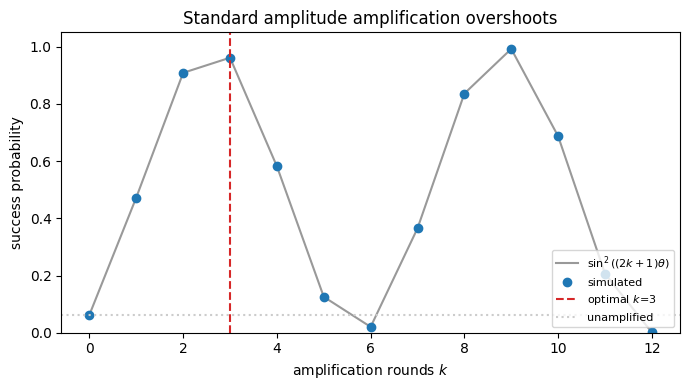

In [6]:
figure, axes = plt.subplots(figsize=(7, 4))
axes.plot(rounds, standard_analytic, "-", color="0.6", label=r"$\sin^2((2k+1)\theta)$")
axes.plot(rounds, standard_measured, "o", color="tab:blue", label="simulated")
axes.axvline(
    optimal_k, color="tab:red", linestyle="--", label=f"optimal $k$={optimal_k}"
)
axes.axhline(initial_probability, color="0.8", linestyle=":", label="unamplified")
axes.set_xlabel("amplification rounds $k$")
axes.set_ylabel("success probability")
axes.set_title("Standard amplitude amplification overshoots")
axes.set_ylim(0.0, 1.05)
axes.legend(loc="lower right", fontsize=8)
figure.tight_layout()
plt.show()

The simulated points sit exactly on the analytic curve, and past $k=3$ the
probability collapses again. Choosing $k$ from a *lower bound* on $a$ rather
than from $a$ itself would therefore be unsafe: too many rounds is as bad as
too few.

## Fixed-point amplification: only a lower bound is needed

The Yoder-Low-Chuang schedule replaces the two hard reflections of each round
with phased reflections. Given $\lambda \le a$ and a target failure tolerance
$\delta$, `qmc.fixed_point_amplification_schedule` derives the smallest odd
query count $L$ for which the output success probability is at least
$1 - \delta^2$ for every $a \ge \lambda$, and returns the schedule object
carrying it.

In [7]:
BOUND = 0.05
TOLERANCE = 0.3

schedule = qmc.fixed_point_amplification_schedule(BOUND, TOLERANCE)
query_count = schedule.query_count

print(f"lower bound lambda  = {BOUND}")
print(f"failure tolerance   = {TOLERANCE}")
print(f"guarantee           = {schedule.guaranteed_success_probability:.2f}")
print(f"query count L       = {query_count}")
print(f"phase schedule      = {len(schedule.phases)} phases "
      f"({schedule.num_rounds} rounds)")
print(f"covers a >= {schedule.admissible_success_probability_bound:.4f}")

lower bound lambda  = 0.05
failure tolerance   = 0.3
guarantee           = 0.91
query count L       = 9
phase schedule      = 8 phases (4 rounds)
covers a >= 0.0421


The schedule holds $L - 1$ phases, interleaved as
`(good_1, zero_1, good_2, zero_2, ...)`. The good-subspace phases are the
reverse of the zero-state phases — the phase-matching condition that makes
the sequence a fixed point.

Note that rounding $L$ up to the next odd integer buys a little extra: the
schedule actually covers every $a$ above
`admissible_success_probability_bound`, which is below the $\lambda$ we
asked for.

In [8]:
def scheduled_kernel(
    target: qmc.IsingZBlockEncoding,
    applied_schedule: qmc.AmplificationSchedule,
) -> qmc.QKernel:
    """Build a kernel measuring success after one amplification schedule.

    Args:
        target (qmc.IsingZBlockEncoding): Block encoding to amplify.
        applied_schedule (qmc.AmplificationSchedule): Schedule to apply.

    Returns:
        qmc.QKernel: Kernel returning the all-zero-signal probability.
    """

    @qmc.qkernel
    def kernel(observable: qmc.Observable) -> qmc.Float:
        """Estimate the all-zero-signal probability.

        Args:
            observable (qmc.Observable): All-zero signal projector.

        Returns:
            qmc.Float: Success probability after amplification.
        """
        signal = qmc.qubit_array(target.num_signal_qubits, "signal")
        system = qmc.qubit_array(target.num_system_qubits, "system")
        signal, _ = qmc.amplitude_amplification(
            signal,
            system,
            target.unitary,
            applied_schedule,
        )
        return qmc.expval(signal, observable)

    return kernel


fixed_point_measured = run(scheduled_kernel(encoding, schedule))
print(f"fixed-point success = {fixed_point_measured:.4f}")
print(f"schedule predicts   = {schedule.success_probability(initial_probability):.4f}")
print(f"guarantee           = {schedule.guaranteed_success_probability:.4f}")
assert fixed_point_measured >= schedule.guaranteed_success_probability - 1e-8
assert abs(
    fixed_point_measured - schedule.success_probability(initial_probability)
) < 1e-8

fixed-point success = 0.9943
schedule predicts   = 0.9943
guarantee           = 0.9100


## The fixed-point guarantee holds across the whole admissible range

One schedule, built from $\lambda$ alone, is now applied to a family of
encodings whose true success probabilities span two orders of magnitude. For
comparison we also apply a standard schedule whose round count was tuned for
$\lambda$ — the best a user could do without knowing $a$.

In [9]:
tuned_k = qmc.amplitude_amplification_iteration_count(BOUND)
tuned_schedule = qmc.standard_amplification_schedule(tuned_k)
sweep = [-0.6, -0.5, -0.45, -0.3, -0.15, 0.0]
true_probabilities = []
fixed_point_values = []
tuned_values = []

for coefficient in sweep:
    swept = build_encoding(coefficient)
    probability = analytic_success_probability(coefficient)
    true_probabilities.append(probability)

    executable = transpiler.transpile(
        scheduled_kernel(swept, schedule),
        bindings={"observable": zero_projector(swept.num_signal_qubits)},
    )
    fixed_point_values.append(float(executable.run(executor).result()))
    tuned_values.append(tuned_schedule.success_probability(probability))

for probability, value in zip(true_probabilities, fixed_point_values):
    assert value >= schedule.guaranteed_success_probability - 1e-8

print(f"standard schedule tuned for lambda: k = {tuned_k}")
for coefficient, probability, fixed, tuned in zip(
    sweep, true_probabilities, fixed_point_values, tuned_values
):
    print(
        f"  c1={coefficient:+.2f}  a={probability:.4f}"
        f"  fixed-point={fixed:.4f}  tuned-standard={tuned:.4f}"
    )

standard schedule tuned for lambda: k = 3
  c1=-0.60  a=0.0625  fixed-point=0.9943  tuned-standard=0.9613
  c1=-0.50  a=0.1111  fixed-point=0.9470  tuned-standard=0.4773
  c1=-0.45  a=0.1439  fixed-point=0.9121  tuned-standard=0.1650
  c1=-0.30  a=0.2899  fixed-point=0.9993  tuned-standard=0.5532
  c1=-0.15  a=0.5463  fixed-point=0.9756  tuned-standard=0.1977
  c1=+0.00  a=1.0000  fixed-point=1.0000  tuned-standard=1.0000


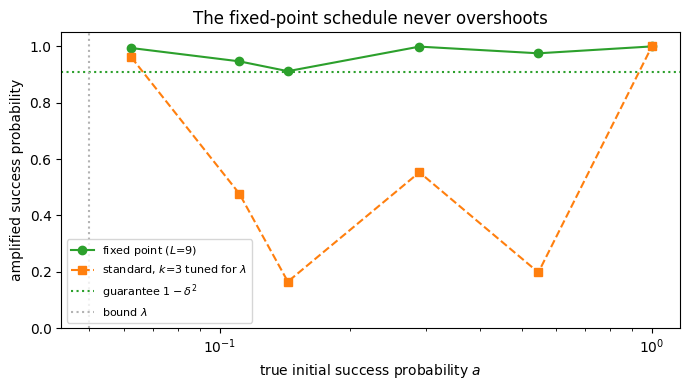

In [10]:
order = np.argsort(true_probabilities)
sorted_probabilities = np.asarray(true_probabilities)[order]
figure, axes = plt.subplots(figsize=(7, 4))
axes.plot(
    sorted_probabilities,
    np.asarray(fixed_point_values)[order],
    "o-",
    color="tab:green",
    label=f"fixed point ($L$={query_count})",
)
axes.plot(
    sorted_probabilities,
    np.asarray(tuned_values)[order],
    "s--",
    color="tab:orange",
    label=rf"standard, $k$={tuned_k} tuned for $\lambda$",
)
axes.axhline(
    schedule.guaranteed_success_probability,
    color="tab:green",
    linestyle=":",
    label=r"guarantee $1-\delta^2$",
)
axes.axvline(BOUND, color="0.7", linestyle=":", label=r"bound $\lambda$")
axes.set_xscale("log")
axes.set_xlabel("true initial success probability $a$")
axes.set_ylabel("amplified success probability")
axes.set_title("The fixed-point schedule never overshoots")
axes.set_ylim(0.0, 1.05)
axes.legend(loc="lower left", fontsize=8)
figure.tight_layout()
plt.show()

The fixed-point curve stays above the guarantee everywhere above $\lambda$,
while the tuned standard schedule is only correct near $\lambda$ and rotates
straight past the target as $a$ grows.

## Cost

Amplification adds a single clean auxiliary qubit, reused by every
reflection, so the circuit uses `num_signal_qubits + num_system_qubits + 1`
qubits in total. A fixed-point sequence of query count $L = 2\ell + 1$
applies the preparation $\ell + 1$ times and its inverse $\ell$ times,
together with $\ell$ pairs of phase rotations.

In [11]:
executable = transpiler.transpile(
    scheduled_kernel(encoding, schedule),
    bindings={"observable": zero_projector(encoding.num_signal_qubits)},
)
circuit = executable.quantum_circuit
operation_names = [
    instruction.operation.name
    for instruction in circuit.data
    if instruction.operation.name != "measure"
]
half_count = schedule.num_rounds

print(f"circuit qubits          = {circuit.num_qubits}")
print(
    f"register qubits + 1     = {encoding.num_signal_qubits + encoding.num_system_qubits + 1}"
)
print(f"encoding applications   = {operation_names.count('ising_z_block_encoding')}")
print(
    f"good phase rotations    = {operation_names.count('amplitude_amplification_good_phase_rotation')}"
)
print(
    f"zero phase rotations    = {operation_names.count('amplitude_amplification_zero_phase_rotation')}"
)

assert circuit.num_qubits == (
    encoding.num_signal_qubits + encoding.num_system_qubits + 1
)
assert operation_names.count("ising_z_block_encoding") == half_count + 1
assert (
    operation_names.count("amplitude_amplification_good_phase_rotation") == half_count
)

circuit qubits          = 3
register qubits + 1     = 3
encoding applications   = 5
good phase rotations    = 4
zero phase rotations    = 4


## Summary

* Block-encoding post-selection succeeds with probability
  $a = \lVert A\lvert\psi\rangle\rVert^2/\alpha^2$, which shrinks as the
  encoded filter sharpens.
* `qmc.standard_amplification_schedule(k)` reaches $\sin^2((2k+1)\theta)$
  exactly, which is optimal only when $a$ is known; otherwise it overshoots.
* `qmc.fixed_point_amplification_schedule(lambda, delta)` needs only a lower
  bound $\lambda \le a$ and guarantees success probability
  $\ge 1 - \delta^2$ for every $a \ge \lambda$, at
  $L = O(\log(2/\delta)/\sqrt{\lambda})$ queries.
* Every schedule answers `success_probability(a)`, so the outcome is
  predictable before any gate is emitted.
* Both cost one extra auxiliary qubit and accept any state preparation with
  the `(signal, system)` block-encoding ABI. Use
  `qmc.amplification_preparation` to bundle a non-zero system input with the
  encoding into an `AmplificationPreparation`, which can also be bound into a
  serialized template.